# WGAN-GP — Wasserstein GAN with Gradient Penalty

This notebook implements **WGAN-GP** (Gulrajani et al., 2017), the answer to the biggest weakness of the original WGAN — its crude weight-clipping.

The Wasserstein formulation requires the critic to be **1-Lipschitz**:

$$\|f(x_1) - f(x_2)\| \leq \|x_1 - x_2\|$$

Vanilla WGAN tried to enforce this by **clipping weights** to a small range. That works in principle, but it's a blunt instrument: it can over-constrain the critic, force pathological weight distributions, or under-constrain it entirely.

WGAN-GP replaces clipping with a **gradient penalty**:

$$L_{GP} = \lambda \, \mathbb{E}_{\hat{x}} \left[ \left( \|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1 \right)^2 \right]$$

The intuition: a 1-Lipschitz function has input-gradients with norm at most 1 *almost everywhere*. So we directly **penalize** the critic when its input-gradient norm deviates from 1.

Three implementation details matter and Module 12 walks through them:

- The gradient is w.r.t. the **input** $\hat{x}$, not the weights
- $\hat{x}$ is sampled by **interpolating** between real and fake samples
- Computing input-gradients needs `torch.autograd.grad` with `create_graph=True` — we need to backprop through a gradient

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

WGAN-GP paper defaults:

- `lr = 1e-4`
- `betas = (0.0, 0.9)` — $\beta_1 = 0$ (no momentum smoothing)
- `n_critic = 5` — critic updates per generator update
- `lambda_gp = 10` — gradient penalty weight

We're back to **Adam** now — the gradient penalty fixes what made vanilla WGAN + Adam unstable.

In [2]:
latent_dim    = 100
img_channels  = 1
img_size      = 64
features_g    = 64
features_c    = 64
batch_size    = 64
lr            = 1e-4
betas         = (0.0, 0.9)
epochs        = 10
n_critic      = 5
lambda_gp     = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('samples_WGAN-GP', exist_ok=True)

Using device: cuda


## 2. Data — MNIST upscaled to 64×64

Same pipeline as DCGAN / WGAN.

In [3]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.96MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


## 3. Weight Initialization

Same DCGAN-style init.

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## 4. The Critic

Identical architecture to WGAN's Critic: strided `Conv2d` blocks with `LeakyReLU`, **no BatchNorm**, **no Sigmoid**.

Spatial flow:

```
64 × 64  →  32 × 32  →  16 × 16  →  8 × 8   →  4 × 4   →  1
   1         64          128         256        512       1
```

The change from WGAN is purely in the **training step**, not in the architecture.

In [5]:
class Critic(nn.Module):
    def __init__(self, img_channels=1, features_c=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, features_c, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_c, features_c * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_c * 2, features_c * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_c * 4, features_c * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_c * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(x.size(0), -1)

## 5. The Generator

Same as before: `ConvTranspose2d` → `BatchNorm` → `ReLU` blocks, ending in `Tanh`.

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=1, features_g=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), z.size(1), 1, 1))

## 6. Models and Optimizers

**Adam** with `betas=(0.0, 0.9)`. Module 12 explains this: $\beta_1 = 0$ means no momentum smoothing. Vanilla WGAN couldn't use Adam because Adam's momentum smoothing interferes with the brittle weight-clipping constraint — but the gradient penalty is a *smooth* objective, so the two play nicely together.

In [7]:
C = Critic(img_channels=img_channels, features_c=features_c).to(device)
G = Generator(latent_dim=latent_dim, img_channels=img_channels, features_g=features_g).to(device)

C.apply(weights_init)
G.apply(weights_init)

optimizer_C = optim.Adam(C.parameters(), lr=lr, betas=betas)
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)

print(C)
print()
print(G)

Critic(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)

## 7. The Gradient Penalty — The Heart of WGAN-GP

Four pieces, each one subtle:

**1. Sample interpolated points**

$$\hat{x} = \epsilon \, x_{real} + (1 - \epsilon) \, x_{fake}, \quad \epsilon \sim U[0,1]$$

$\hat{x}$ lives on the line between a real image and a fake one. We use `.detach()` on the fake so this step doesn't accidentally drag gradients into $G$'s parameters.

**2. Mark `\hat{x}` as a leaf that needs gradients**

`.requires_grad_(True)` — PyTorch only tracks gradients through tensors that opt in. Without this, we can't take $\nabla_{\hat{x}} C(\hat{x})$.

**3. Compute the gradient w.r.t. the input**

`torch.autograd.grad(outputs=d_inter, inputs=interpolated, create_graph=True, retain_graph=True)[0]`.

`create_graph=True` is essential: it builds a graph of the gradient computation itself, so when we backprop through the penalty, the gradient-of-the-gradient flows back to the critic's weights. This is computationally more expensive than normal training — we're computing second-order gradients.
**4. Penalize deviation from unit norm**

$(\nabla_{x} \cdot \nabla_{x})^\frac{1}{2}$ is the per-sample L2 norm; we square its distance from 1 and take the mean.

In [8]:
def compute_gradient_penalty(C, real_imgs, fake_imgs, device):
    """
    Compute the gradient penalty:
      L_GP = lambda * E[(||grad_x C(x_hat)||_2 - 1)^2]
    where x_hat is a random interpolation between a real and a fake sample.
    """
    b = real_imgs.size(0)

    # alpha ~ U[0, 1], broadcast to image shape
    alpha = torch.rand(b, 1, 1, 1, device=device)

    # Interpolated point along the line between real and fake
    # .detach() on fake so this isn't backpropped into G
    # .requires_grad_(True) so we CAN backprop w.r.t. x_hat
    interpolated = (alpha * real_imgs + (1 - alpha) * fake_imgs.detach()).requires_grad_(True)

    # Critic score at the interpolated point
    d_inter = C(interpolated)

    # Gradient of C(x_hat) w.r.t. x_hat itself
    gradients = torch.autograd.grad(
        outputs=d_inter,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_inter),
        create_graph=True,    # so the penalty can backprop into the critic
        retain_graph=True,    # graph is reused by the main backward pass
    )[0]

    # (b, c*h*w) -> per-sample L2 norm
    gradients = gradients.view(b, -1)
    grad_norm = gradients.norm(2, dim=1)

    # (||grad|| - 1)^2, then mean
    gradient_penalty = ((grad_norm - 1) ** 2).mean()
    return gradient_penalty

## 8. The Training Loop

Critic loss now has three pieces:

$$L_C = E[D(x_{fake})] - E[D(x_{real})] + \lambda_{GP} \cdot L_{GP}$$

Generator loss is unchanged from WGAN: minimize $-E[D(G(z))]$ — i.e., push the critic's score on fakes upward.

In [9]:
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

w_distances = []
gp_values   = []
losses_g    = []

G.train()
C.train()

for epoch in range(epochs):
    epoch_w   = 0.0
    epoch_gp  = 0.0
    epoch_g   = 0.0
    n_batches = 0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        # -----------------
        # Phase A: Train Critic (n_critic times)
        # -----------------
        for _ in range(n_critic):
            optimizer_C.zero_grad()

            real_score = C(real_imgs)

            z = torch.randn(b, latent_dim, 1, 1, device=device)
            with torch.no_grad():
                gen_imgs = G(z)
            fake_score = C(gen_imgs)

            # Wasserstein distance estimate
            w_estimate = real_score.mean() - fake_score.mean()

            # Gradient penalty (computed using gen_imgs with grad,
            # but the GP itself only updates the critic)
            gp = compute_gradient_penalty(C, real_imgs, gen_imgs, device)

            # Critic loss = -W + lambda * GP
            c_loss = -w_estimate + lambda_gp * gp
            c_loss.backward()
            optimizer_C.step()

        # -----------------
        # Phase B: Train Generator (once)
        # -----------------
        optimizer_G.zero_grad()

        gen_imgs = G(z)
        validity = C(gen_imgs)
        g_loss   = -validity.mean()
        g_loss.backward()
        optimizer_G.step()

        epoch_w  += w_estimate.item()
        epoch_gp += gp.item()
        epoch_g  += g_loss.item()
        n_batches += 1

    avg_w  = epoch_w  / n_batches
    avg_gp = epoch_gp / n_batches
    avg_g  = epoch_g  / n_batches
    w_distances.append(avg_w)
    gp_values.append(avg_gp)
    losses_g.append(avg_g)

    print(
        f"Epoch [{epoch+1}/{epochs}]  "
        f"W: {avg_w:.4f}  GP: {avg_gp:.4f}  G: {avg_g:.4f}"
    )

    G.eval()
    with torch.no_grad():
        sample_imgs = G(fixed_noise).detach().cpu()
    save_image(sample_imgs, f"samples_WGAN-GP/epoch_{epoch+1:02d}.png", nrow=8, normalize=True)
    G.train()

print('Training done.')

Epoch [1/10]  W: 26.9701  GP: 0.6739  G: -14.4283
Epoch [2/10]  W: 10.3070  GP: 0.1324  G: -1.9324
Epoch [3/10]  W: 9.3481  GP: 0.1131  G: -2.0016
Epoch [4/10]  W: 8.3381  GP: 0.0943  G: -2.5999
Epoch [5/10]  W: 7.6579  GP: 0.0805  G: -3.0373
Epoch [6/10]  W: 7.2083  GP: 0.0733  G: -3.0499
Epoch [7/10]  W: 6.8539  GP: 0.0660  G: -2.9413
Epoch [8/10]  W: 6.5235  GP: 0.0610  G: -2.9805
Epoch [9/10]  W: 6.2769  GP: 0.0567  G: -2.9956
Epoch [10/10]  W: 6.1141  GP: 0.0552  G: -3.1904
Training done.


## 9. Generating New Samples

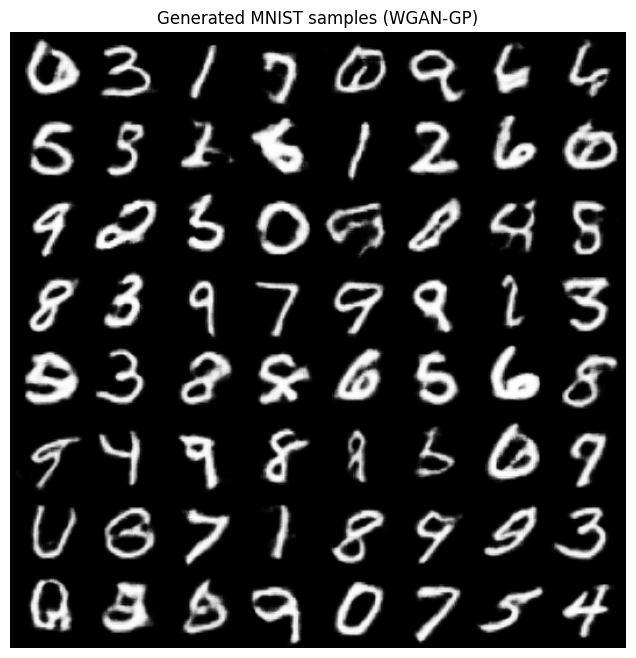

In [10]:
G.eval()
with torch.no_grad():
    samples = G(torch.randn(64, latent_dim, 1, 1, device=device)).cpu()

grid = make_grid(samples, nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Generated MNIST samples (WGAN-GP)')
plt.show()

## 10. Training Progression

In [11]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(2.2 * len(paths), 2.2))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0])
        ax.axis('off')
    plt.suptitle('Generator progression across epochs')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

No sample grids found. Run the training cell first.


## 11. Loss Curves — Three Numbers Worth Tracking

- **$\hat{W}$** — the Wasserstein distance estimate. Should trend toward 0 as distributions converge.
- **GP** — gradient penalty. Should hover near a small positive number. If it explodes, $\lambda$ is likely too high.
- **G loss** — pushes the critic's score on fakes up. Negative numbers, more-negative = better fakes.

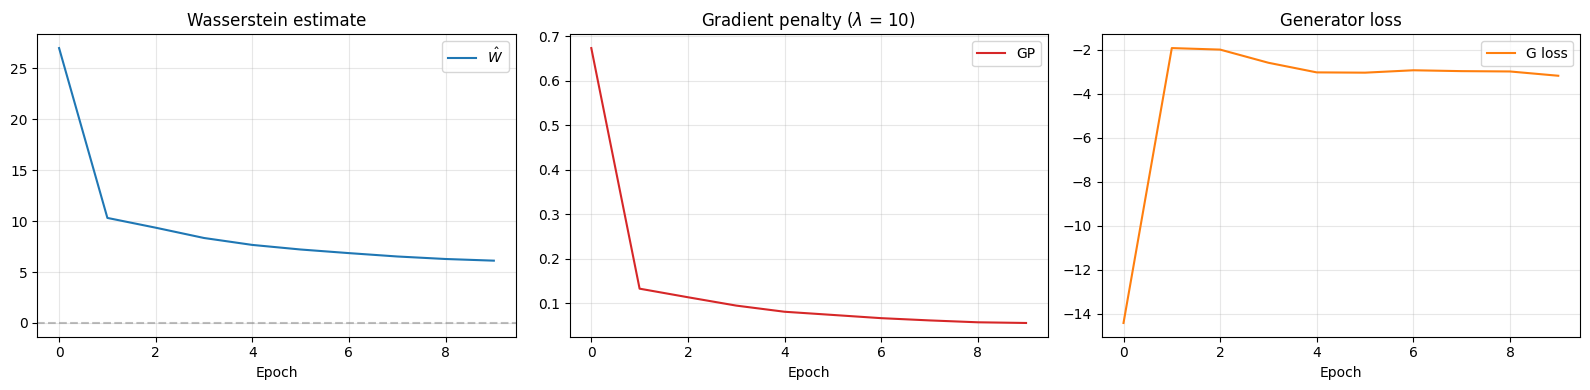

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(w_distances, label=r'$\hat{W}$', color='tab:blue')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_title('Wasserstein estimate')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(gp_values, label='GP', color='tab:red')
axes[1].set_xlabel('Epoch')
axes[1].set_title(f'Gradient penalty ($\\lambda$ = {lambda_gp})')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(losses_g, label='G loss', color='tab:orange')
axes[2].set_xlabel('Epoch')
axes[2].set_title('Generator loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recap — How WGAN-GP Differs From WGAN

| Concern | WGAN | WGAN-GP |
|---|---|---|
| Lipschitz constraint | **weight clipping** | **gradient penalty** |
| Constraint hyperparam | `clip_value` (sensitive) | $\lambda_{GP}$ |
| Optimizer | RMSProp | **Adam** (with $\beta_1 = 0$) |
| LR | 5e-5 | **1e-4** |
| Critic loss | $-\hat{W}$ | $-\hat{W} + \lambda_{GP} \cdot L_{GP}$ |
| Extra Critic work per step | none | one forward through interpolated samples + autograd on input |
| Critic architecture | no BN, no Sigmoid | same |
| Generator architecture | same | same |

Architecture is unchanged from WGAN. Only the **training step** got more sophisticated: we replaced a hard constraint (clipping) with a soft one (penalty on input-gradient norm), at the cost of an extra forward pass and an autograd call per Critic step.

**Common implementation pitfalls** (Module 12 §25) — quick reference:

- Don't add a `Sigmoid` at the end of the critic.
- Don't reach for `BCE` — the loss is a direct Wasserstein estimate.
- The gradient in $L_{GP}$ must be w.r.t. **$\hat{x}$**, not the weights.
- Don't forget `requires_grad_(True)` on the interpolated samples.
- Don't forget `create_graph=True` — without it, the gradient penalty won't backprop into the critic.
- Use `fake.detach()` during the Critic step so the gradient doesn't sneak into $G$.

WGAN-GP is one of the most-used GAN training recipes in practice. From here the curriculum typically moves to **Conditional GANs** (controllable generation), **Spectral Normalization**, or progressively-grown GANs like **StyleGAN**.

In [13]:
import zipfile
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = 'samples_WGAN-GP'
zip_file_name = f'{directory_to_zip}.zip'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(directory_to_zip):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

print(f"'{directory_to_zip}' has been successfully zipped into '{zip_file_name}'")

# Offer the zip file for download
files.download(zip_file_name)

'samples_WGAN-GP' has been successfully zipped into 'samples_WGAN-GP.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>